In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environnement IA prêt ✅")

Environnement IA prêt ✅


In [4]:
from pathlib import Path

dataset_path = Path("../data/smartphones.csv")

print("Dataset trouvé :", dataset_path.exists())
print("Chemin :", dataset_path)

Dataset trouvé : True
Chemin : ..\data\smartphones.csv


In [5]:
df = pd.read_csv(dataset_path)

print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

display(df.head())

Nombre de lignes : 758
Nombre de colonnes : 27


,smartphone_brand,model,price_inr,rating_score,processor_name,processor_brand,core_count,clock_speed_ghz,ram_gb,storage_gb,...,battery_mah,fast_charging,charging_watt,rear_camera_count,front_camera_count,rear_camera_main_mp,front_camera_main_mp,os_name,memory_card_supported,memory_card_type
0,blackzone,BlackZone S25 Ultra Maxx,8999,63,unisoc sc9863a1,unisoc,8,1.6,8,128,...,5000,False,10.0,1,1,32.0,16.0,android,NaN,NaN
1,ringme,Ringme Bold P70,5800,44,mediatek helio,mediatek,2,1.3,4,128,...,3260,False,10.0,1,0,13.0,NaN,android,NaN,NaN
2,lava,Lava Shark 5G (4GB RAM + 128GB),8998,60,unisoc t765,unisoc,8,2.3,4,128,...,5000,True,10.0,1,1,13.0,5.0,android,True,dedicated
3,vivo,Vivo Y19s 5G (4GB RAM + 128GB),11999,69,mediatek dimensity 6300,mediatek,8,2.4,4,128,...,6000,True,15.0,2,1,13.0,5.0,android,True,dedicated
4,vivo,Vivo Y19s 5G (4GB RAM + 64GB),10999,68,mediatek dimensity 6300,mediatek,8,2.4,4,64,...,6000,True,15.0,2,1,13.0,5.0,android,True,dedicated


In [6]:
# Informations générales sur le dataset
print("Dimensions :", df.shape)

print("\nTypes des colonnes :")
print(df.dtypes)

print("\nValeurs manquantes :")
print(df.isnull().sum())

Dimensions : (758, 27)

Types des colonnes :
smartphone_brand          object
model                     object
price_inr                  int64
rating_score               int64
processor_name            object
processor_brand           object
core_count                 int64
clock_speed_ghz          float64
ram_gb                     int64
storage_gb                 int64
has_5g                      bool
has_nfc                     bool
has_ir_blaster              bool
display_inches           float64
res_width_px               int64
res_height_px              int64
refresh_rate_hz            int64
battery_mah                int64
fast_charging               bool
charging_watt            float64
rear_camera_count          int64
front_camera_count         int64
rear_camera_main_mp      float64
front_camera_main_mp     float64
os_name                   object
memory_card_supported     object
memory_card_type          object
dtype: object

Valeurs manquantes :
smartphone_brand           0

In [7]:
# Vérification des doublons
print("Nombre de doublons :", df.duplicated().sum())

# Copie du dataset pour travailler proprement
df_clean = df.copy()

# Valeurs manquantes de la caméra frontale :
# remplacement par la médiane
df_clean["front_camera_main_mp"] = df_clean["front_camera_main_mp"].fillna(
    df_clean["front_camera_main_mp"].median()
)

# Pour les cartes mémoire :
# une valeur manquante signifie ici qu'aucune information n'est renseignée
df_clean["memory_card_supported"] = df_clean["memory_card_supported"].fillna(False)
df_clean["memory_card_type"] = df_clean["memory_card_type"].fillna("Non disponible")

print("Valeurs manquantes après nettoyage :")
print(df_clean.isnull().sum())

Nombre de doublons : 0
Valeurs manquantes après nettoyage :
smartphone_brand         0
model                    0
price_inr                0
rating_score             0
processor_name           0
processor_brand          0
core_count               0
clock_speed_ghz          0
ram_gb                   0
storage_gb               0
has_5g                   0
has_nfc                  0
has_ir_blaster           0
display_inches           0
res_width_px             0
res_height_px            0
refresh_rate_hz          0
battery_mah              0
fast_charging            0
charging_watt            0
rear_camera_count        0
front_camera_count       0
rear_camera_main_mp      0
front_camera_main_mp     0
os_name                  0
memory_card_supported    0
memory_card_type         0
dtype: int64


C:\Users\saadi anissa\AppData\Local\Temp\ipykernel_13232\3499228458.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["memory_card_supported"] = df_clean["memory_card_supported"].fillna(False)


In [8]:
# Statistiques descriptives
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
price_inr,758.0,29424.088391,32989.687389,4040.00,11857.25,18999.0,29990.00,229900.00
rating_score,758.0,78.587071,8.372894,37.00,74.00,80.0,84.00,97.00
core_count,758.0,7.906332,0.701338,1.00,8.00,8.0,8.00,10.00
clock_speed_ghz,758.0,2.597889,0.596162,1.00,2.30,2.4,2.80,4.47
ram_gb,758.0,7.990765,3.134361,2.00,6.00,8.0,8.00,24.00
storage_gb,758.0,220.496042,168.366358,32.00,128.00,128.0,256.00,2048.00
display_inches,758.0,6.697810,0.285648,3.75,6.67,6.7,6.77,8.03
res_width_px,758.0,1043.919525,260.683929,128.00,720.00,1080.0,1206.00,2400.00
res_height_px,758.0,2234.897098,494.157749,160.00,1612.00,2400.0,2532.00,3168.00
refresh_rate_hz,758.0,114.182058,18.061720,60.00,120.00,120.0,120.00,165.00


In [9]:
# Prix moyen par marque
df_clean.groupby("smartphone_brand")["price_inr"].mean().sort_values(ascending=False).head(15)


smartphone_brand
apple       124709.821429
google       92040.272727
ulefone      86500.000000
oneplus      48019.050000
samsung      43086.048077
honor        33662.333333
nothing      28506.285714
vivo         28336.361702
iqoo         25330.655172
oppo         25112.253731
motorola     23944.425000
realme       19798.835821
tecno        18914.225806
infinix      17902.321429
cmf          17187.000000
Name: price_inr, dtype: float64

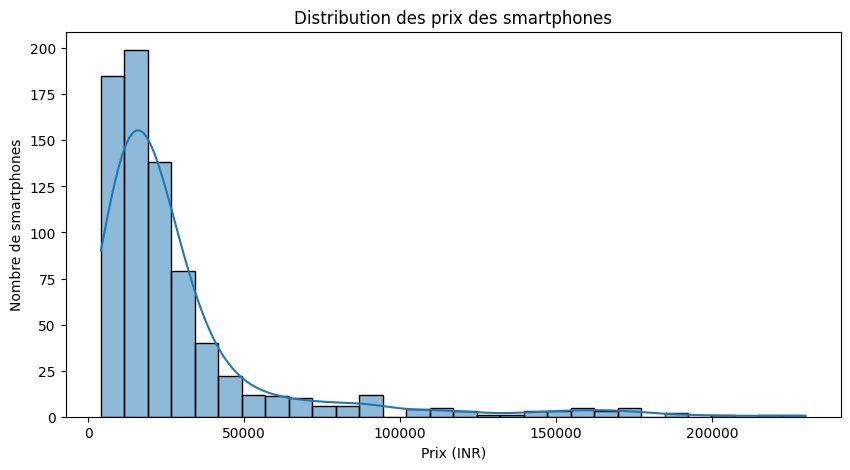

In [10]:
# Distribution des prix
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["price_inr"], bins=30, kde=True)
plt.title("Distribution des prix des smartphones")
plt.xlabel("Prix (INR)")
plt.ylabel("Nombre de smartphones")
plt.show()

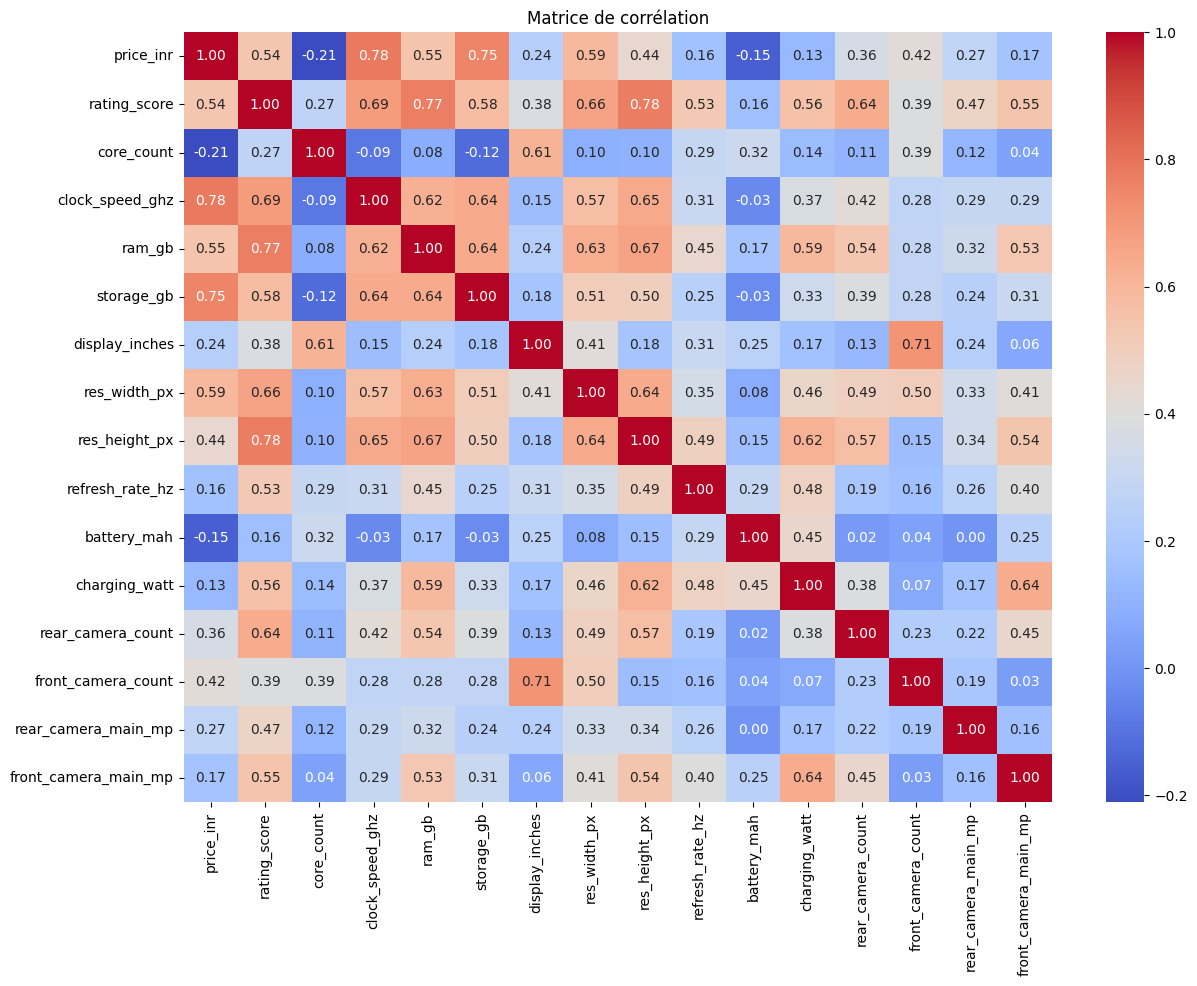

In [11]:
# Corrélations entre les variables numériques
corr = df_clean.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

In [12]:
# Préparation des données pour le Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Variable cible
y = df_clean["price_inr"]

# Variables utilisées pour prédire le prix
features = [
    "smartphone_brand",
    "rating_score",
    "processor_brand",
    "core_count",
    "clock_speed_ghz",
    "ram_gb",
    "storage_gb",
    "has_5g",
    "has_nfc",
    "has_ir_blaster",
    "display_inches",
    "res_width_px",
    "res_height_px",
    "refresh_rate_hz",
    "battery_mah",
    "fast_charging",
    "charging_watt",
    "rear_camera_count",
    "front_camera_count",
    "rear_camera_main_mp",
    "front_camera_main_mp",
    "os_name",
    "memory_card_supported"
]

X = df_clean[features]

print("X :", X.shape)
print("y :", y.shape)

X : (758, 23)
y : (758,)


In [13]:
# Séparation des données en entraînement et test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Données d'entraînement :", X_train.shape)
print("Données de test :", X_test.shape)

Données d'entraînement : (606, 23)
Données de test : (152, 23)


In [14]:
# Identification des variables numériques et catégorielles

categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variables catégorielles :")
print(categorical_features)

print("\nVariables numériques :")
print(numeric_features)

Variables catégorielles :
['smartphone_brand', 'processor_brand', 'has_5g', 'has_nfc', 'has_ir_blaster', 'fast_charging', 'os_name', 'memory_card_supported']

Variables numériques :
['rating_score', 'core_count', 'clock_speed_ghz', 'ram_gb', 'storage_gb', 'display_inches', 'res_width_px', 'res_height_px', 'refresh_rate_hz', 'battery_mah', 'charging_watt', 'rear_camera_count', 'front_camera_count', 'rear_camera_main_mp', 'front_camera_main_mp']


In [15]:
# Préparation du prétraitement

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

print("Préprocesseur créé avec succès ✅")

Préprocesseur créé avec succès ✅


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Modèle de régression
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)

# Pipeline complet : prétraitement + modèle
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

# Entraînement
pipeline.fit(X_train, y_train)

print("Modèle entraîné avec succès ✅")

Modèle entraîné avec succès ✅


In [17]:
# Prédictions sur les données de test

y_pred = pipeline.predict(X_test)

# Calcul des performances
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE  :", round(mae, 2), "INR")
print("RMSE :", round(rmse, 2), "INR")
print("R²   :", round(r2, 4))

MAE  : 3625.83 INR
RMSE : 8254.16 INR
R²   : 0.891


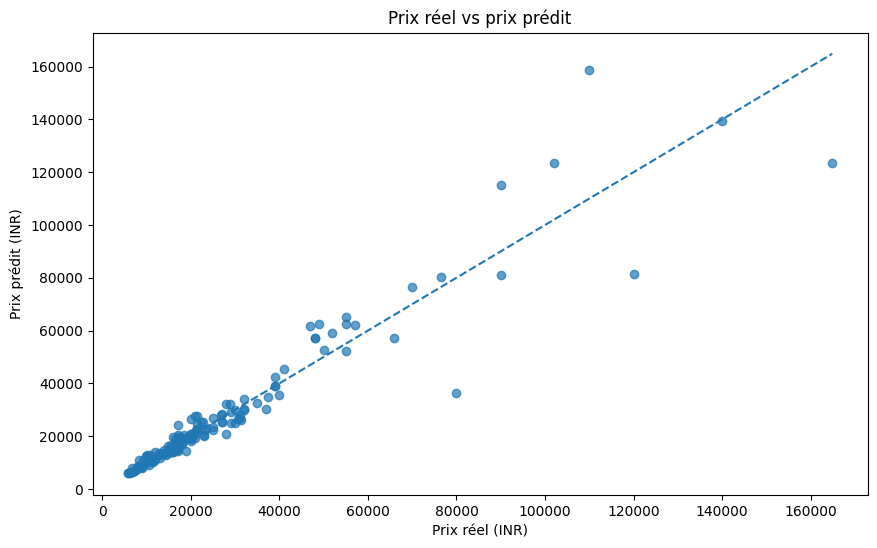

In [18]:
# Comparaison entre les prix réels et les prix prédits

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Prix réel (INR)")
plt.ylabel("Prix prédit (INR)")
plt.title("Prix réel vs prix prédit")
plt.show()

In [19]:
# Test de prédiction sur un smartphone

smartphone_test = pd.DataFrame([{
    "smartphone_brand": "samsung",
    "processor_brand": "snapdragon",
    "has_5g": True,
    "has_nfc": True,
    "has_ir_blaster": False,
    "fast_charging": True,
    "os_name": "android",
    "memory_card_supported": False,
    "rating_score": 85,
    "core_count": 8,
    "clock_speed_ghz": 3.0,
    "ram_gb": 8,
    "storage_gb": 256,
    "display_inches": 6.6,
    "res_width_px": 1080,
    "res_height_px": 2340,
    "refresh_rate_hz": 120,
    "battery_mah": 5000,
    "charging_watt": 45,
    "rear_camera_count": 3,
    "front_camera_count": 1,
    "rear_camera_main_mp": 50,
    "front_camera_main_mp": 12
}])

prediction = pipeline.predict(smartphone_test)

print("Prix prédit :", round(prediction[0], 2), "INR")

Prix prédit : 40188.74 INR


In [20]:
import joblib
from pathlib import Path

model_path = Path("../models/price_predictor.joblib")

joblib.dump(pipeline, model_path)

print("Modèle sauvegardé ✅")
print("Emplacement :", model_path)

Modèle sauvegardé ✅
Emplacement : ..\models\price_predictor.joblib
